# fMRI Spatial Signatures of Unresponsiveness

This notebook explores spatial patterns of brain activity using fMRI.

Goals:

- Compare sleep and propofol-induced unresponsiveness
- Visualize mean BOLD activity
- Examine voxel intensity distributions
- Quantify signal variability
- Explore spatial signatures of reduced consciousness

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from nilearn import plotting

In [2]:
sleep_img = nib.load(
    "../data/raw/sleep_data/sub_23/fmri/sub-23_task-sleep_run-3_bold.nii.gz"
)

prop_img = nib.load(
    "../data/raw/propofol_data/sub-02_task-rest_run-1_bold.nii.gz"
)

## Dataset Overview

In [3]:
print("Sleep shape:", sleep_img.shape)
print("Propofol shape:", prop_img.shape)

Sleep shape: (80, 80, 35, 429)
Propofol shape: (64, 64, 21, 770)


## Mean BOLD Activity

We average signal intensity across time to obtain a representative spatial pattern.

In [4]:
sleep_data = sleep_img.get_fdata()
prop_data = prop_img.get_fdata()

sleep_mean = sleep_data.mean(axis=3)
prop_mean = prop_data.mean(axis=3)

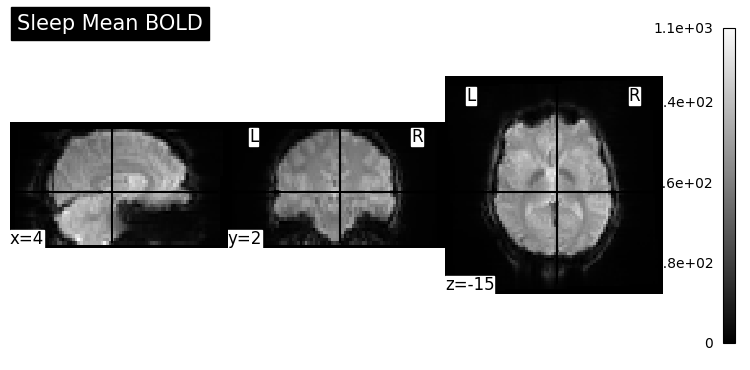

In [22]:
sleep_mean_img = nib.Nifti1Image(
    sleep_mean,
    sleep_img.affine
)

plotting.plot_img(
    sleep_mean_img,
    title="Sleep Mean BOLD"
)

plotting.show()

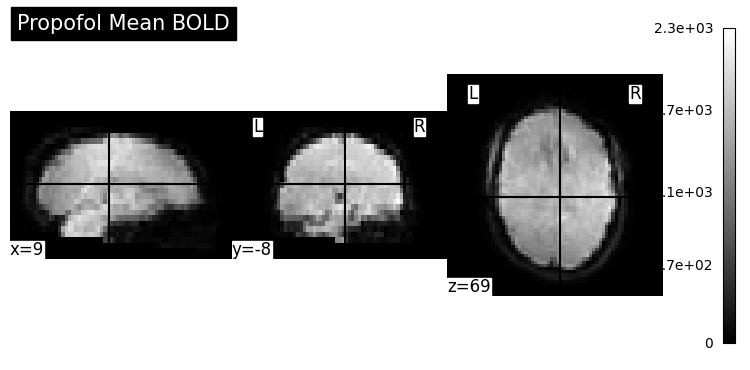

In [6]:
prop_mean_img = nib.Nifti1Image(
    prop_mean,
    prop_img.affine
)

plotting.plot_img(
    prop_mean_img,
    title="Propofol Mean BOLD"
)

plotting.show()

### Interpretation

Mean BOLD maps provide a coarse representation of spatial signal distribution across the brain.

These maps do not directly represent neural activity, but rather average hemodynamic signal intensity over the acquisition period.

## Signal Variability

In [9]:
sleep_std = sleep_data.std(axis=3)

prop_std = prop_data.std(axis=3)

In [23]:
sleep_data_z = (
    sleep_data - sleep_data.mean()
) / sleep_data.std()

prop_data_z = (
    prop_data - prop_data.mean()
) / prop_data.std()

In [24]:
sleep_std = sleep_data_z.std(axis=3)

prop_std = prop_data_z.std(axis=3)

In [25]:
sleep_std_mean = sleep_std.mean()

prop_std_mean = prop_std.mean()

print("Sleep variability:", sleep_std_mean)
print("Propofol variability:", prop_std_mean)

Sleep variability: 0.015277687499928725
Propofol variability: 0.012421181538373047


Natural sleep is a dynamic process (involving phase transitions, micro-arousals, and slow-wave activity), which is reflected in the higher variability of the BOLD signal. Propofol, in contrast, acts as a global depressant (via enhanced GABAergic inhibition), leading to a more homogeneous, suppressed metabolic state and a reduction in the amplitude of signal fluctuations.

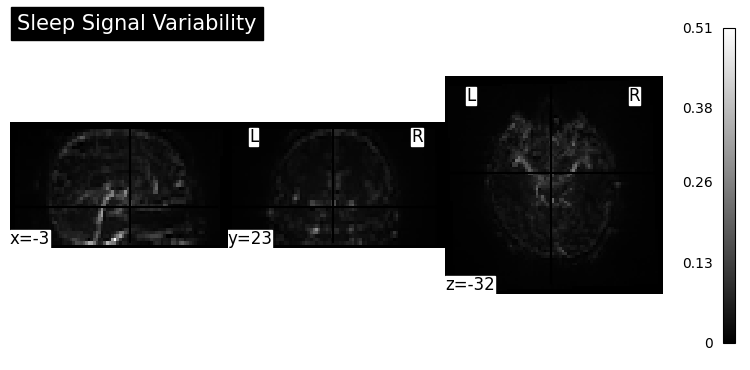

In [26]:
sleep_std_img = nib.Nifti1Image(
    sleep_std,
    sleep_img.affine
)

plotting.plot_img(
    sleep_std_img,
    title="Sleep Signal Variability"
)

plotting.show()

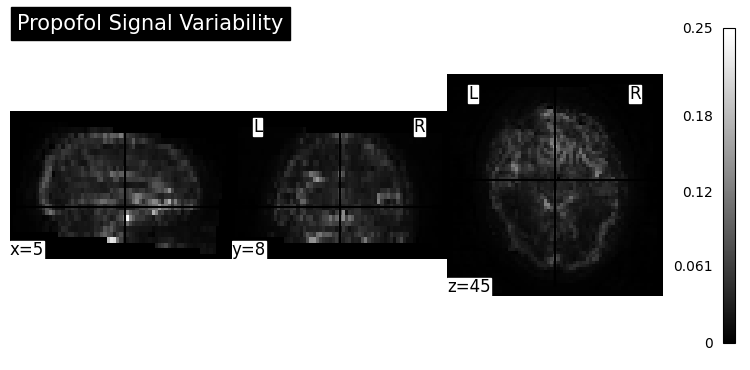

In [27]:
prop_std_img = nib.Nifti1Image(
    prop_std,
    prop_img.affine
)

plotting.plot_img(
    prop_std_img,
    title="Propofol Signal Variability"
)

plotting.show()

In [14]:
from scipy.stats import entropy

In [29]:
sleep_hist, _ = np.histogram(
    sleep_voxels,
    bins=100,
    density=True
)

prop_hist, _ = np.histogram(
    prop_voxels,
    bins=100,
    density=True
)

sleep_entropy = entropy(
    sleep_hist + 1e-10
)

prop_entropy = entropy(
    prop_hist + 1e-10
)

print("Sleep entropy:", sleep_entropy)
print("Propofol entropy:", prop_entropy)

Sleep entropy: 2.4237781498201816
Propofol entropy: 2.5101931749574224


Although the overall signal variability decreases, its spatial unpredictability (entropy) increases. This indicates spatial fragmentation. During sleep, the brain maintains highly organized functional networks (e.g., the Default Mode Network). Propofol disrupts this global connectivity architecture, transforming structured activity into a more chaotic, disintegrated (entropic) distribution of isolated signals.

# Conclusions

Key findings:

- Mean BOLD maps revealed distinct spatial activity patterns in sleep and propofol datasets.
- Temporal signal variability provided a simple measure of brain dynamics.
- Propofol and natural sleep may produce similar behavioral outcomes while exhibiting different spatial signatures in fMRI.

Together with EEG-based complexity measures, these results provide a multimodal perspective on altered states of consciousness.